In [1]:
from main import *

# DES Dovekie + DESI DR2 (no unbounded parameters)

In [36]:
# initialising object
lcdm_sn_bao = cosmo_model("./lcdm_chains/DD+DESI", burnin=0.5)
cpl_sn_bao = cosmo_model("./cpl_chains/DD+DESI", burnin=0.5)

## getting parameter constraints from getdist

In [3]:
# specify viewing parameters (including Omega_b to test adding derived parameters)
lcdm_params = ["H0", "omega_b", "omega_cdm", "Omega_b", "Omega_m", "S8"]
cpl_params = lcdm_params + ["w0_fld", "wa_fld"]
lcdm_sn_bao.set_display_params(lcdm_params)
cpl_sn_bao.set_display_params(cpl_params)

# checking convergence
print(f"LCDM R-1 = {lcdm_sn_bao.get_gelman_rubin()}")
print(f"CPL R-1 = {cpl_sn_bao.get_gelman_rubin()}")

./lcdm_chains/DD+DESI.1.txt
./lcdm_chains/DD+DESI.2.txt
./lcdm_chains/DD+DESI.3.txt
./lcdm_chains/DD+DESI.4.txt
Removed 0.5 as burn in
LCDM R-1 = 0.009448838358317401
./cpl_chains/DD+DESI.1.txt
./cpl_chains/DD+DESI.2.txt
./cpl_chains/DD+DESI.3.txt
./cpl_chains/DD+DESI.4.txt
Removed 0.5 as burn in
CPL R-1 = 0.0043811481886642245


In [4]:
# getting 1 sigma constraints on requested parameters
print("LCDM constraints:")
lcdm_constraints = lcdm_sn_bao.get_params()
print("-----------")
print("CPL constraints:")
cpl_constraints = cpl_sn_bao.get_params()

LCDM constraints:


H_0 = 72^{+10}_{-4}
\Omega_\mathrm{b} h^2 = 0.0266^{+0.013}_{-0.0076}
\Omega_\mathrm{c} h^2 = 0.134^{+0.032}_{-0.018}
\Omega_b = 0.0487^{+0.010}_{-0.0019}
\Omega_\mathrm{m} = 0.3056\pm 0.0077
S_8 = 0.82^{+0.21}_{-0.38}
-----------
CPL constraints:
H_0 = 71^{+10}_{-5}
\Omega_\mathrm{b} h^2 = 0.0267^{+0.013}_{-0.0046}
\Omega_\mathrm{c} h^2 = 0.132\pm 0.029
\Omega_b = 0.0505^{+0.012}_{-0.0041}
\Omega_\mathrm{m} = 0.313^{+0.017}_{-0.011}
S_8 = 0.80^{+0.19}_{-0.38}
w_{0,\mathrm{DE}} = -0.840^{+0.064}_{-0.074}
w_{a,\mathrm{DE}} = -0.55\pm 0.47


## Estimating the Bayesian evidence using MCEvidence

In [37]:
# specify the sampled parameters used for MCMC
lcdm_sampled_params = ["H0", "omega_b", "omega_cdm", "logA", "n_s"]
cpl_sampled_params = lcdm_sampled_params + ["w0_fld", "wa_fld"]
lcdm_sn_bao.set_sampled_params(lcdm_sampled_params)
cpl_sn_bao.set_sampled_params(cpl_sampled_params)
# getting ln Evidence
print(f"LCDM ln Evidence = {lcdm_sn_bao.mcevidence}")
print(f"CPL ln Evidence = {cpl_sn_bao.mcevidence}")

RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ./lcdm_chains/DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=5.186315999999998
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=5
INFO:MCEvidence.py.setup():162      Loading chain from ./lcdm_chains/DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ./lcdm_chains/DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 1462 lines as burn in
INFO:MC

ln(B)[k=1] = -832.0763449019962


LCDM ln Evidence = -832.0763449019962
RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ./cpl_chains/DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=103.72631999999996
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=7
INFO:MCEvidence.py.setup():162      Loading chain from ./cpl_chains/DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ./cpl_chains/DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/DD+DESI_BE.1.txt
INFO:MCEvidence.py.removeBurn():423      Removing 9420 lines as burn in
INFO:MCEviden

ln(B)[k=1] = -833.9740305484995


CPL ln Evidence = -833.9740305484995


In [38]:
# get bayes factor between two models
print(f"ln Z_LCDM - ln Z_CPL = {lcdm_sn_bao.get_MCE_bayes_factor(cpl_sn_bao)}")

$\ln\mathcal{Z}_\mathrm{MCE}$: 1.898
ln Z_LCDM - ln Z_CPL = 1.8976856465033052


## Estimating bayesian evidence using Harmonic

Training NF: 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]


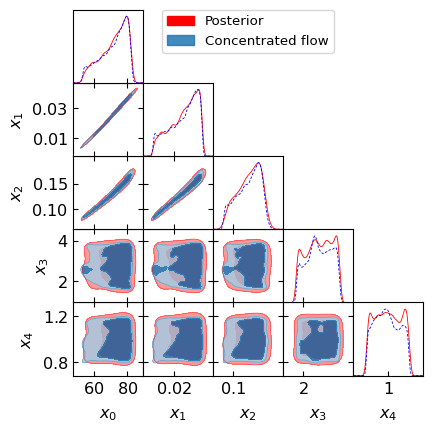

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 50/50 [05:28<00:00,  6.58s/it]


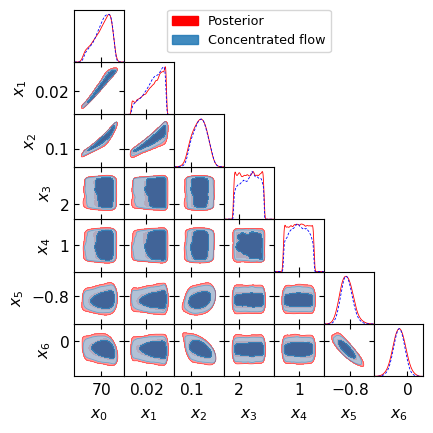

ensure that the concentrated flow is contained within the posterior


In [39]:
# train models
lcdm_sn_bao.train_model(epochs=50, temp=0.8, verbose=True)
cpl_sn_bao.train_model(epochs=50, temp=0.8, verbose=True)

# if there is a saved model, can load instead
# lcdm_sn_bao.load_model()
# cpl_sn_bao.load_model()

In [40]:
# perform diagnostics test to see if the trained flow provides a reliable estimate
print("LCDM diagnostics:")
lcdm_sn_bao.check_harmonic_diagnostics()
print("-----------")
print("CPL diagnostics:")
cpl_sn_bao.check_harmonic_diagnostics()

LCDM diagnostics:
=== Harmonic Estimator Diagnostics ===
Max Weight Fraction: 0.0015 (Should be < 0.01)
Fractional ESS:      0.6873 (Higher is better)
Pareto-k Diagnostic: -0.0523
SUCCESS: Pareto-k < 0.5. The flow is strictly contained. Evidence is reliable.
-----------
CPL diagnostics:
=== Harmonic Estimator Diagnostics ===
Max Weight Fraction: 0.0001 (Should be < 0.01)
Fractional ESS:      0.7233 (Higher is better)
Pareto-k Diagnostic: -0.0551
SUCCESS: Pareto-k < 0.5. The flow is strictly contained. Evidence is reliable.


(np.float64(-0.05511321841585437), np.float32(0.7232606))

In [41]:
# get evidence from the trained model
lcdm_ev, lcdm_ev_err = lcdm_sn_bao.get_hm_evidence(train_model=False)
cpl_ev, cpl_ev_err = cpl_sn_bao.get_hm_evidence(train_model=False)
print(f"LCDM HM Evidence = {lcdm_ev} +/- {lcdm_ev_err}")
print(f"CPL HM Evidence = {cpl_ev} +/- {cpl_ev_err}")

LCDM HM Evidence = 832.3907470703125 +/- (np.float32(-0.00975644), np.float32(0.009662171))
CPL HM Evidence = 834.0919799804688 +/- (np.float32(-0.002848207), np.float32(0.0028401774))


In [42]:
# checking if loading gives the same evidence
load_test = cosmo_model("./lcdm_chains/DD+DESI", burnin=0.5)
load_test.set_sampled_params(lcdm_sampled_params)
ev_test, ev_test_err = load_test.get_hm_evidence(train_model=False, temp=0.8)
print(f"Loaded model HM Evidence = {ev_test} +/- {ev_test_err}")

Loaded model HM Evidence = 832.3907470703125 +/- (np.float32(-0.009757042), np.float32(0.009662761))


In [43]:
lcdm_sn_bao.get_LMHE_bayes_factor(cpl_sn_bao)

$\ln\mathcal{Z}_\mathrm{LHME}$: 1.701 + 0.010 / - 0.010


(np.float32(1.7012329), np.float32(0.010073223), np.float32(0.010161433))

# Adding CMB datasets (gaussian prior on tau)

In [29]:
# initialising object
lcdm_all = cosmo_model("./lcdm_chains/ts_CMB-SPA+DD+DESI")
cpl_all = cosmo_model("./cpl_chains/ts_CMB-SPA+DD+DESI", burnin=0.5)

## getting parameter constraints from getdist

In [13]:
# specify viewing parameters (including Omega_b to test adding derived parameters)
lcdm_params = [
    "theta_s_100",
    "logA",
    "n_s",
    "tau_reio",
    "omega_b",
    "omega_cdm",
    "H0",
    "S8",
]
cpl_params = lcdm_params + ["w0_fld", "wa_fld"]
lcdm_all.set_display_params(lcdm_params)
cpl_all.set_display_params(cpl_params)

# checking convergence
print(f"LCDM R-1 = {lcdm_all.get_gelman_rubin()}")
print(f"CPL R-1 = {cpl_all.get_gelman_rubin()}")

LCDM R-1 = 0.00819280250382877
CPL R-1 = 0.009385908497231667


In [14]:
# getting 1 sigma constraints on requested parameters
print("LCDM constraints:")
lcdm_constraints = lcdm_all.get_params()
print("-----------")
print("CPL constraints:")
cpl_constraints = cpl_all.get_params()

LCDM constraints:
100\theta_\mathrm{s} = 1.04178\pm 0.00022
\log(10^{10} A_\mathrm{s}) = 3.0594\pm 0.0096
n_\mathrm{s} = 0.9732\pm 0.0029
\tau_\mathrm{reio} = 0.0590\pm 0.0053
\Omega_\mathrm{b} h^2 = 0.022464\pm 0.000090
\Omega_\mathrm{c} h^2 = 0.11842\pm 0.00058
H_0 = 68.14\pm 0.24
S_8 = 0.8198\pm 0.0063
-----------
CPL constraints:
100\theta_\mathrm{s} = 1.04168\pm 0.00023
\log(10^{10} A_\mathrm{s}) = 3.048\pm 0.010
n_\mathrm{s} = 0.9709\pm 0.0030
\tau_\mathrm{reio} = 0.0550\pm 0.0055
\Omega_\mathrm{b} h^2 = 0.022424\pm 0.000096
\Omega_\mathrm{c} h^2 = 0.11958\pm 0.00077
H_0 = 67.49\pm 0.56
S_8 = 0.8324\pm 0.0071
w_{0,\mathrm{DE}} = -0.802\pm 0.056
w_{a,\mathrm{DE}} = -0.75^{+0.23}_{-0.20}


## Estimating the Bayesian evidence using MCEvidence

In [30]:
# specify the sampled parameters used for MCMC
lcdm_sampled_params = [
    "theta_s_100",
    "omega_b",
    "omega_cdm",
    "logA",
    "n_s",
    "tau_reio;0.9999995",
    "Tcal;0.9999995",
    "Ecal",
    "A_planck",
    "P_act",
]
cpl_sampled_params = lcdm_sampled_params + ["w0_fld", "wa_fld"]
lcdm_all.set_sampled_params(lcdm_sampled_params)
cpl_all.set_sampled_params(cpl_sampled_params)
# getting ln Evidence
print(f"LCDM ln Evidence = {lcdm_all.mcevidence}")
print(f"CPL ln Evidence = {cpl_all.mcevidence}")

RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.00014339502693393465
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=10
INFO:MCEvidence.py.setup():162      Loading chain from ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./lcdm_chains/ts_CMB-SPA+DD+DESI_BE.1.

ln(B)[k=1] = -1174.740553549458


LCDM ln Evidence = -1174.740553549458
RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.002867900538678693
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=12
INFO:MCEvidence.py.setup():162      Loading chain from ./cpl_chains/ts_CMB-SPA+DD+DESI_BE
INFO:MCEvidence.py.load_from_file():664       loading files: ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():633      loading: ./cpl_chains/ts_CMB-SPA+DD+DESI_BE.1.txt
INFO:

ln(B)[k=1] = -1175.0168025346716


CPL ln Evidence = -1175.0168025346716


In [31]:
# get bayes factor between two models
print(f"ln Z_LCDM - ln Z_CPL = {lcdm_all.get_MCE_bayes_factor(cpl_all)}")

$\ln\mathcal{Z}_\mathrm{MCE}$: 0.276
ln Z_LCDM - ln Z_CPL = 0.2762489852136696


## Estimating the Bayesian evidence using MCEvidence

Training NF: 100%|██████████| 50/50 [01:20<00:00,  1.60s/it]


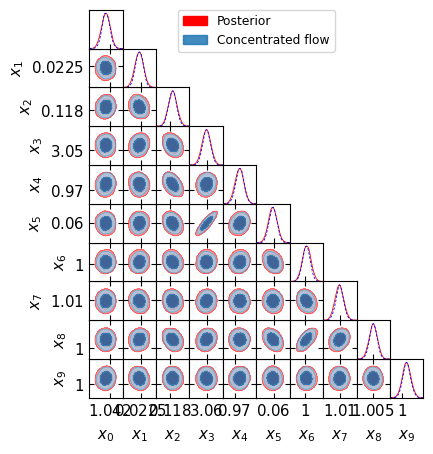

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 50/50 [02:54<00:00,  3.50s/it]


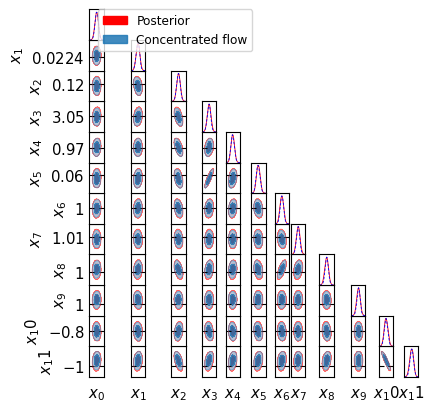

ensure that the concentrated flow is contained within the posterior


In [32]:
# train models
lcdm_all.train_model(epochs=50, temp=0.8, verbose=True)
cpl_all.train_model(epochs=50, temp=0.8, verbose=True)

# if there is a saved model, can load instead
# lcdm_all.load_model()
# cpl_all.load_model()

In [33]:
# perform diagnostics test to see if the trained flow provides a reliable estimate
print("LCDM diagnostics:")
lcdm_all.check_harmonic_diagnostics()
print("-----------")
print("CPL diagnostics:")
cpl_all.check_harmonic_diagnostics()

LCDM diagnostics:
=== Harmonic Estimator Diagnostics ===
Max Weight Fraction: 0.0002 (Should be < 0.01)
Fractional ESS:      0.6492 (Higher is better)
Pareto-k Diagnostic: -0.5121
SUCCESS: Pareto-k < 0.5. The flow is strictly contained. Evidence is reliable.
-----------
CPL diagnostics:
=== Harmonic Estimator Diagnostics ===
Max Weight Fraction: 0.0003 (Should be < 0.01)
Fractional ESS:      0.6113 (Higher is better)
Pareto-k Diagnostic: 0.0505
SUCCESS: Pareto-k < 0.5. The flow is strictly contained. Evidence is reliable.


(np.float64(0.05053042095085894), np.float32(0.6113304))

In [34]:
# get evidence from the trained model
lcdm_ev, lcdm_ev_err = lcdm_all.get_hm_evidence(train_model=False)
cpl_ev, cpl_ev_err = cpl_all.get_hm_evidence(train_model=False)
print(f"LCDM HM Evidence = {lcdm_ev} +/- {lcdm_ev_err}")
print(f"CPL HM Evidence = {cpl_ev} +/- {cpl_ev_err}")

LCDM HM Evidence = 1175.4544677734375 +/- (np.float32(-0.007832425), np.float32(0.007771613))
CPL HM Evidence = 1174.4249267578125 +/- (np.float32(-0.023284065), np.float32(0.022754172))


In [35]:
lcdm_all.get_LMHE_bayes_factor(cpl_all)

$\ln\mathcal{Z}_\mathrm{LHME}$: -1.030 + 0.024 / - 0.025


(np.float32(-1.029541), np.float32(0.024546804), np.float32(0.02406448))